In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True)

#landmark indices
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]
LEFT_PUPIL = 468
RIGHT_PUPIL = 473
LEFT_EYEBROW = [70, 63, 105, 66, 107]
RIGHT_EYEBROW = [336, 296, 334, 293, 300]

def euclidean_distance(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

I0000 00:00:1773053086.155821       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [2]:
def extract_features(image_path):
    image = cv2.imread(image_path)
    if image is None: return None
    
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb_image)
    
    if not results.multi_face_landmarks:
        return None
        
    landmarks = results.multi_face_landmarks[0].landmark
    h, w, _ = image.shape
    pts = [(int(pt.x * w), int(pt.y * h)) for pt in landmarks]
    
    l_p0, l_p1, l_p2, l_p3, l_p4, l_p5 = [pts[i] for i in LEFT_EYE]
    r_p0, r_p1, r_p2, r_p3, r_p4, r_p5 = [pts[i] for i in RIGHT_EYE]
    
    lear = (euclidean_distance(l_p1, l_p5) + euclidean_distance(l_p2, l_p4)) / (2.0 * euclidean_distance(l_p0, l_p3))
    rear = (euclidean_distance(r_p1, r_p5) + euclidean_distance(r_p2, r_p4)) / (2.0 * euclidean_distance(r_p0, r_p3))
    avg_ear = (lear + rear) / 2.0
    
    left_eye_width = euclidean_distance(l_p0, l_p3)
    left_eye_height = (euclidean_distance(l_p1, l_p5) + euclidean_distance(l_p2, l_p4)) / 2.0
    right_eye_width = euclidean_distance(r_p0, r_p3)
    right_eye_height = (euclidean_distance(r_p1, r_p5) + euclidean_distance(r_p2, r_p4)) / 2.0
    
    left_openness = left_eye_height / (left_eye_width + 1e-6)
    right_openness = right_eye_height / (right_eye_width + 1e-6)
    
    l_dist = left_eye_height
    r_dist = right_eye_height
    
    pupil_visibility = (left_eye_height + right_eye_height) / 2.0
    
    l_eyebrow_center = pts[105]
    r_eyebrow_center = pts[334]
    left_eyebrow_dist = euclidean_distance(l_p1, l_eyebrow_center)
    right_eyebrow_dist = euclidean_distance(r_p1, r_eyebrow_center)
    
    return [
        lear, rear, avg_ear, left_eye_width, left_eye_height,
        right_eye_width, right_eye_height, left_openness, right_openness,
        l_dist, r_dist, pupil_visibility, left_eyebrow_dist, right_eyebrow_dist
    ]

In [ ]:
# Extracting features from all images
folders = {
    'dataset/open': 0,
    'dataset/closed': 1
}

data = []
failed = 0
processed = 0

for folder, label in folders.items():
    if not os.path.exists(folder): continue
    images = os.listdir(folder)
    for img_name in tqdm(images, desc=f"Processing {folder}"):
        if not img_name.endswith(('.jpg', '.png', '.jpeg')): continue
        path = os.path.join(folder, img_name)
        
        try:
            features = extract_features(path)
            if features is not None:
                features.append(label)
                data.append(features)
                processed += 1
            else:
                failed += 1
        except Exception as e:
            failed += 1

columns = [
    'EAR_left', 'EAR_right', 'EAR_avg',
    'left_eye_width', 'left_eye_height', 'right_eye_width', 'right_eye_height',
    'left_openness', 'right_openness', 'left_eyelid_dist', 'right_eyelid_dist',
    'pupil_visibility', 'left_eyebrow_dist', 'right_eyebrow_dist', 'label'
]

df = pd.DataFrame(data, columns=columns)
df.to_csv('features.csv', index=False)
print(f"Total Processed: {processed}")
print(f"Total Failed: {failed}")
print(f"Saved {len(df)} rows to features.csv")

Processing dataset/closed: 100%|██████████| 866/866 [00:11<00:00, 73.99it/s]

Total Processed: 1766
Total Failed: 0
Saved 1766 rows to features.csv


### Visualizations

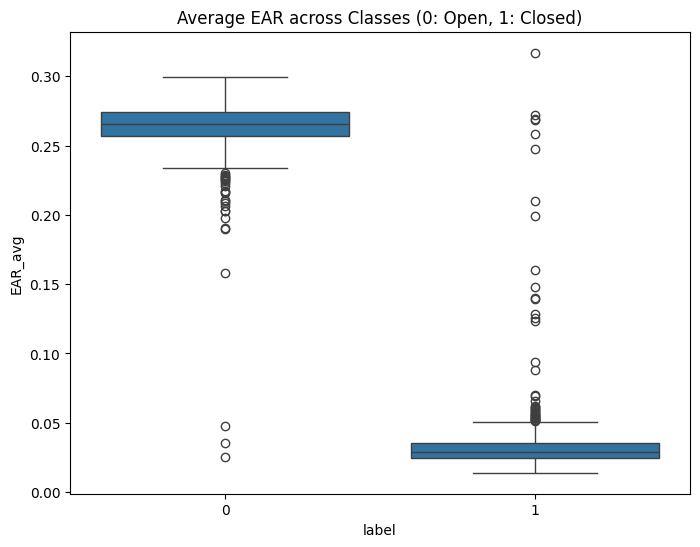

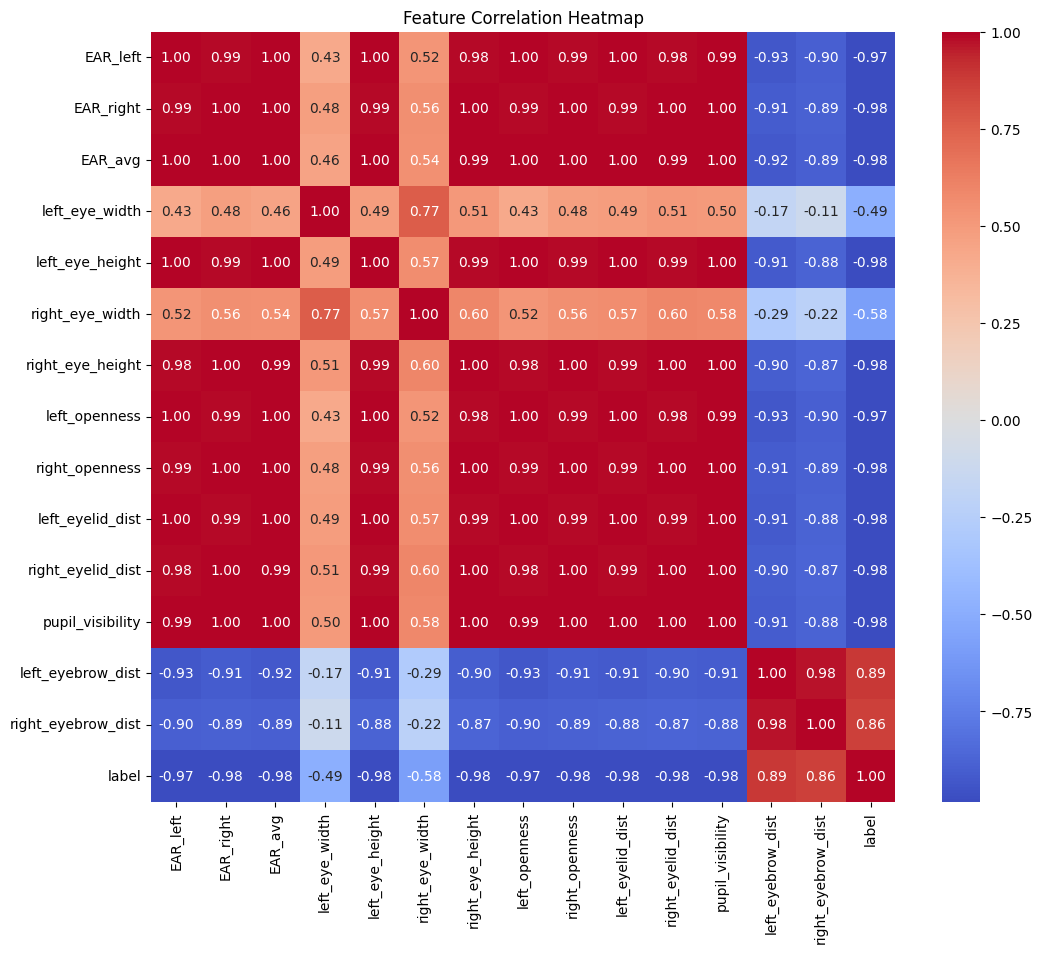

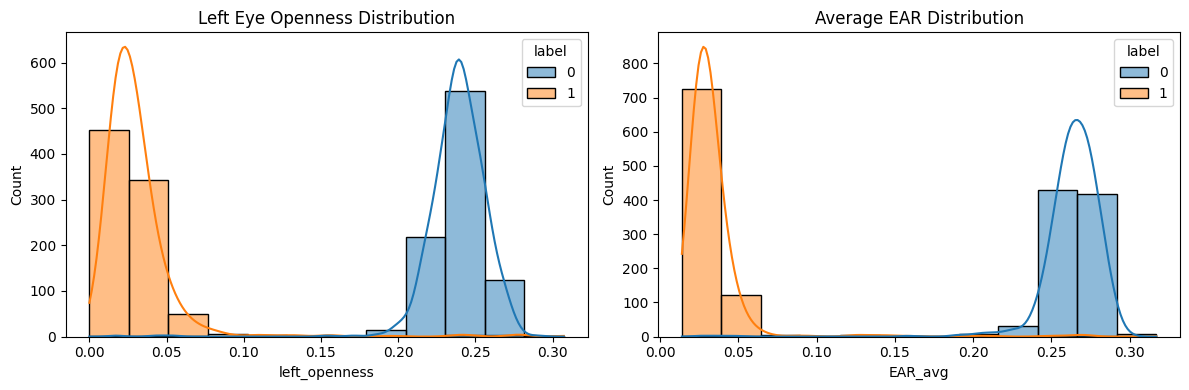

In [5]:
# 1. EAR Box Plot
plt.figure(figsize=(8,6))
sns.boxplot(x='label', y='EAR_avg', data=df)
plt.title("Average EAR across Classes (0: Open, 1: Closed)")
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# 3. Distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df, x='left_openness', hue='label', kde=True, ax=axes[0])
axes[0].set_title("Left Eye Openness Distribution")
sns.histplot(df, x='EAR_avg', hue='label', kde=True, ax=axes[1])
axes[1].set_title("Average EAR Distribution")
plt.tight_layout()
plt.show()